In [61]:
from data_loading import *
from common_processing import *
from visualizing import *

from statsmodels.distributions.empirical_distribution import ECDF

from pyextremes import get_extremes, EVA
from pyextremes.plotting import plot_extremes
import scipy.stats as sstats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r, genpareto, expon

In [62]:
project_dir = 'D:\\InProbation\\Metocean\\'
data_dir = project_dir + 'Data\\'

fname_metadata = 'Model_calibration_metadata.xlsx' 
working_dir = project_dir + 'Analysis\\'

vars_metadata = pd.read_excel(working_dir + fname_metadata, sheet_name='Water', header=1)

stations = vars_metadata['Name'].dropna()
providers = vars_metadata['Provider'].dropna()

checking_year = 2024
vars_dtype = ['datetime64[ns]', 'float']
stations

0    성산포
1     제주
2    서귀포
3    모슬포
4    거문도
Name: Name, dtype: object

In [63]:
i=0 # testing Seongsanpo (0), Seoguipo (2) for extreme water level   
print(f'Running EVA for {stations[i]},{providers[i]}')

Running EVA for 성산포,KHOA


In [64]:
if providers[i] == 'KHOA':
    time_stamp = '관측시간'
    
elif providers[i] == 'KMA':
    time_stamp = '일시'

vars_type = [time_stamp, '조위(cm)']


checking_durations = vars_metadata['Data available'][i]
checking_durations = checking_durations.split('-')
checking_years = np.arange(int(checking_durations[0]), int(checking_durations[1]), 1)
all_year_data = pd.DataFrame(columns=vars_type)

for checking_year in checking_years:

    data = load_obs_all_data(dir_data + 'Observations\\', providers[i], stations[i], checking_year)
    water_data = data[vars_type].astype(dict(zip(vars_type, vars_dtype)))
    water_data = water_data.groupby(pd.Grouper(key=vars_type[0], freq='1h')).mean().reset_index()

    all_year_data = pd.concat([all_year_data, water_data])



C:\Users\User\AppData\Local\Temp\ipykernel_17204\597384780.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_year_data = pd.concat([all_year_data, water_data])
d:\InProbation\Metocean\scripts\data_loading.py:44: DtypeWarning: Columns (1,2,8,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(matching_files[0], sep='\t', skiprows=3,)
d:\InProbation\Metocean\scripts\data_loading.py:44: DtypeWarning: Columns (1,2,3,8,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(matching_files[0], sep='\t', skiprows=3,)
d:\InProbation\Metocean\scripts\data_loading.py:44: DtypeWarning: Columns (2,3,8,10,11,12) have mixed types. Specify dtype op

In [65]:
all_year_data.columns = ['Time', 'Water level [m]']
all_year_data = all_year_data.set_index('Time')
msl = all_year_data.mean()
all_year_data = (all_year_data - msl) # convert to meter
msl = msl/100
all_year_data = all_year_data/100 # convert to meter
all_year_data = all_year_data.dropna()



In [ ]:
eva_model = EVA(all_year_data['Water level [m]'])
eva_model.get_extremes(method="BM", extremes_type='high', block_size="365.2425D")
eva_model.plot_extremes()
plt.show()


In [ ]:
data_excerpt = all_year_data['Water level [m]'].loc['2006-01-01':'2006-01-20']
data_excerpt = all_year_data['Water level [m]']

r = '36h'
threshold = 1.3
extremes = get_extremes(data_excerpt, method='POT', threshold=threshold, r=r)
plot_extremes(
    ts=data_excerpt,
    extremes=extremes,
    extremes_method="POT",
    extremes_type="high",
    threshold=threshold,
    r=r,
)
plt.show()

In [ ]:
from pyextremes import plot_mean_residual_life
plot_mean_residual_life(data_excerpt)
plt.show()

from pyextremes import plot_parameter_stability
plot_parameter_stability(data_excerpt)
plt.show()

from pyextremes import plot_return_value_stability
plot_return_value_stability(
    data_excerpt,
    return_period=100,
    thresholds=np.linspace(1.3, 1.5, 10),
    alpha=0.95
)
plt.show()

224


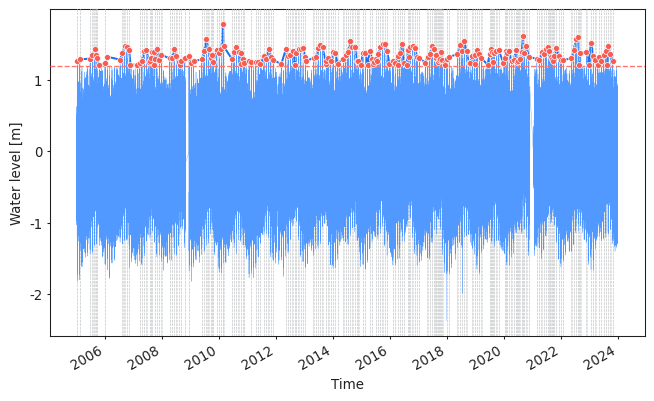

In [66]:
data_excerpt = all_year_data['Water level [m]']

# get 0.5 events per year
# low_extremes = get_extremes(data_excerpt, method='BM', block_size=pd.to_timedelta('365.2425D')/5)
r = '36h'
threshold = 1.2
msl = data_excerpt.mean()
low_extremes = get_extremes(data_excerpt, extremes_type='high', 
                            method='POT', r='36h', threshold=threshold)


plot_extremes(
    ts=data_excerpt,
    extremes=low_extremes,
    extremes_method="POT",
    extremes_type="high",
    threshold=threshold,
    r=r,
)
print(len(low_extremes))
plt.plot(low_extremes)
plt.show()


In [ ]:
# choose number of events per year
from scipy.stats import gumbel_r, expon, weibull_max, genpareto


names_dists = ['gumbel_r', 'expon', 'weibull_max', 'genpareto']
list_dists = [gumbel_r, expon, weibull_max, genpareto]
return_value_100year = dict(zip(names_dists, np.zeros((5, 1))))

for i, events_pear_year in enumerate(range(1, 6)):

    total_events = events_pear_year * len(checking_years)
    threshold = np.quantile(low_extremes, 1-total_events/len(low_extremes))
    extremes = get_extremes(data_excerpt, extremes_type='high', 
                                method='POT', r='36h', threshold=threshold)
    plot_extremes(
        ts=data_excerpt,
        extremes=extremes,
        extremes_method="POT",
        extremes_type="high",
        threshold=threshold,
        r=r,
    )
    #plt.plot(extremes)
    #plt.show()
    eva_model = EVA.from_extremes(extremes, method='POT', extremes_type='high', r=r)
    
    for di in list_dists:
        eva_model.fit_model(model='MLE', distribution=list_dists[di])
        summary = eva_model.get_summary(
            return_period=[1.1, 2, 5, 10, 25, 50, 100, 250, 500, 1000],
            alpha=0.95,
            n_samples=1000,
        )

        eva_model.plot_diagnostic(alpha=0.95)
        #plt.show()

        #print(eva_model)
        #print(summary)

        return_value_100year[i] = summary['return value'][summary.index==100]
    del extremes
    del eva_model
    del summary

c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\pyextremes\eva.py:1058: RuntimeWarning: 'gumbel_r' distribution is not recommended to be used with extremes extracted using the 'POT' method, 'genpareto' or 'expon' should be used per the Pickands-Balkema-de Haan theorem
  warnings.warn(
c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\pyextremes\eva.py:1058: RuntimeWarning: 'gumbel_r' distribution is not recommended to be used with extremes extracted using the 'POT' method, 'genpareto' or 'expon' should be used per the Pickands-Balkema-de Haan theorem
  warnings.warn(
c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\pyextremes\eva.py:1058: RuntimeWarning: 'gumbel_r' distribution is not recommended to be used with extremes extracted using the 'POT' method, 'genpareto' or 'expon' should be used per the Pickands-Balkema-de Haan theorem
  warnings.warn(
c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\pyextremes\eva.py:1058: RuntimeWarning: 'gumbel_r' distributio

In [83]:
return_value_100year 

array([[1.70008143],
       [1.65593327],
       [1.64526672],
       [1.64996864],
       [1.66665742]])

In [76]:

summary

,return value,lower ci,upper ci
return period,,,
1.1,1.473070,1.455780,1.493783
2.0,1.500050,1.478054,1.525698
5.0,1.539859,1.511550,1.573399
10.0,1.569426,1.536802,1.608667
25.0,1.608216,1.568542,1.655181
50.0,1.637457,1.592204,1.690717
100.0,1.666657,1.615844,1.725636
250.0,1.705230,1.647794,1.772100
500.0,1.734399,1.672253,1.807287


In [ ]:
eva_model.fit_model(model='MLE', distribution='gumbel_r')
#eva_model.fit_model()
summary = eva_model.get_summary(
    return_period=[1.1, 2, 5, 10, 25, 50, 100, 250, 500, 1000],
    alpha=0.95,
    n_samples=1000,
)
eva_model
summary

In [ ]:
eva_model


In [ ]:
eva_model.plot_diagnostic(alpha=0.95)
plt.show()

In [ ]:
del eva_model
eva_model = EVA(all_year_data['Water level [m]'])
eva_model.get_extremes(method="BM", extremes_type='low', block_size="365.2425D")
eva_model.plot_extremes()
plt.show()
eva_model.fit_model(model='MLE', distribution='gumbel_r')
#eva_model.fit_model()
summary = eva_model.get_summary(
    return_period=[1.1, 2, 5, 10, 25, 50, 100, 250, 500, 1000],
    alpha=0.95,
    n_samples=1000,
)
summary

In [ ]:
eva_model.plot_diagnostic(alpha=0.95)
plt.show()

In [ ]:
eva_model
